In [1]:
# 1. Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# 2. Load dataset
data= fetch_california_housing(as_frame=True)
df=pd.concat([data.data, data.target.rename("HousePrice")], axis=1)
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
#Separate features and target variable
X=df.drop("HousePrice", axis=1)
y=df["HousePrice"]

In [4]:

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
# 5. Define models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=6, random_state=42)
}

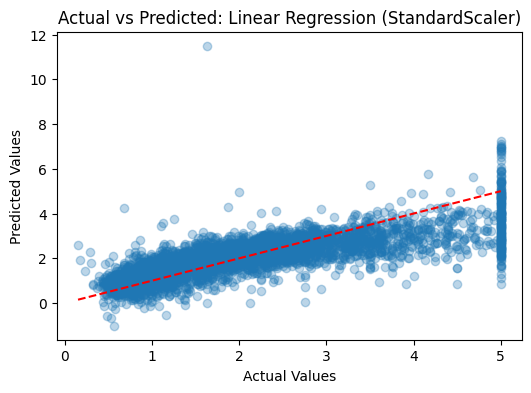

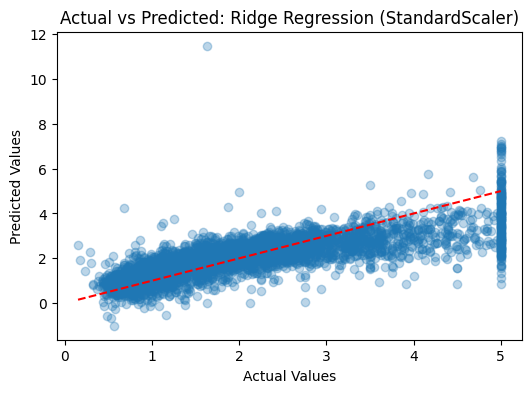

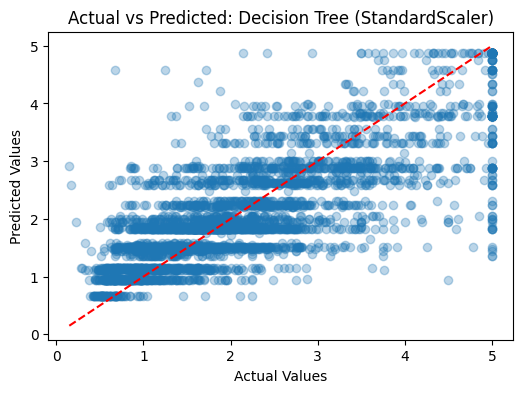

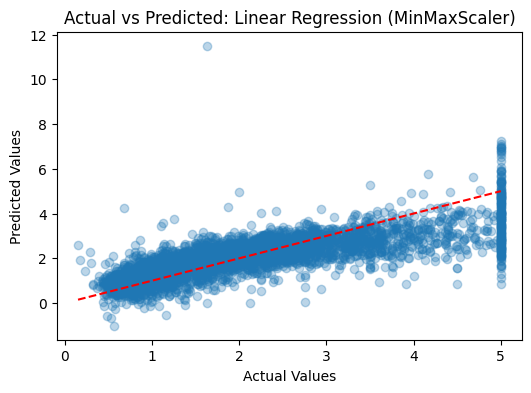

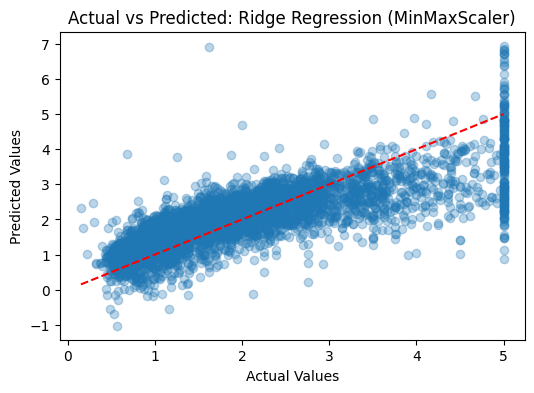

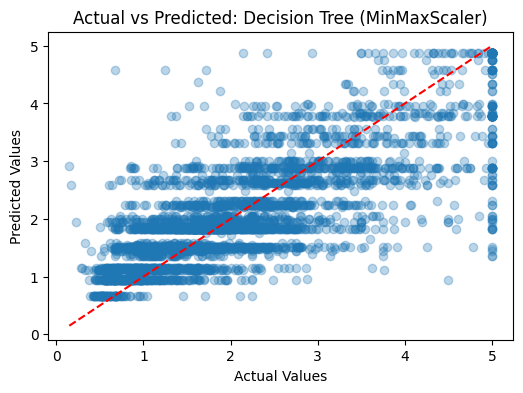

Combined Model Evaluation Results:
           Scaler              Model      RMSE        R²
0  StandardScaler  Linear Regression  0.745581  0.575788
1  StandardScaler   Ridge Regression  0.745557  0.575816
2  StandardScaler      Decision Tree  0.705184  0.620513
3    MinMaxScaler  Linear Regression  0.745581  0.575788
4    MinMaxScaler   Ridge Regression  0.738520  0.583785
5    MinMaxScaler      Decision Tree  0.705184  0.620513


In [6]:
# Feature Scaling and Model Evaluation
scalers = {
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler()
}
results = []

# Ensure 'models' dictionary from cell o4CCKndCkRcU is available.

for scaler_name, scaler in scalers.items():
    # Fit scaler on training data
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train and evaluate each model for the current scaler
    for model_name, model_instance in models.items():
        model_instance.fit(X_train_scaled, y_train)
        y_pred = model_instance.predict(X_test_scaled)

        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        results.append({
            "Scaler": scaler_name,
            "Model": model_name,
            "RMSE": rmse,
            "R²": r2
        })

        # Visualization: Actual vs Predicted for the current model and scaler
        plt.figure(figsize=(6, 4))
        plt.scatter(y_test, y_pred, alpha=0.3)
        plt.xlabel("Actual Values")
        plt.ylabel("Predicted Values")
        plt.title(f"Actual vs Predicted: {model_name} ({scaler_name})")
        plt.plot([y_test.min(), y_test.max()],
                 [y_test.min(), y_test.max()],
                 'r--')  # reference line
        plt.show()

results_df = pd.DataFrame(results)
print("Combined Model Evaluation Results:")
print(results_df)

In [7]:
# 8. Results summary
results_df = pd.DataFrame(results)
print(results_df)

           Scaler              Model      RMSE        R²
0  StandardScaler  Linear Regression  0.745581  0.575788
1  StandardScaler   Ridge Regression  0.745557  0.575816
2  StandardScaler      Decision Tree  0.705184  0.620513
3    MinMaxScaler  Linear Regression  0.745581  0.575788
4    MinMaxScaler   Ridge Regression  0.738520  0.583785
5    MinMaxScaler      Decision Tree  0.705184  0.620513
